In [ ]:
%pip install puremacro


# Frontier DSGE: Discretionary Policy, DSGE-VAR, and Anticipated News Shocks

**How do central banks balance stabilization against credibility when policy is re-optimized each period, how can we discipline vector autoregressions with microfounded general equilibrium priors, and how do forward-looking agents react to news before fundamentals change?**

Linearized DSGE models usually assume a fixed instrument rule (a Taylor rule) and shocks that arrive as surprises. This notebook works through three extensions:

1. **Discretion versus commitment** (Oudiz & Sachs 1985; Clarida, Galí & Gertler 1999; Dennis 2007):
   A policymaker who cannot bind its successors re-optimizes every period, taking private-sector expectations as given. With an output target above potential ($y^* > 0$) this produces the Kydland-Prescott / Barro-Gordon **inflation bias**, and after cost-push shocks it produces a **stabilization bias**: discretion cannot promise the persistent response that commitment uses to steer expectations.

2. **DSGE-VAR** (Del Negro & Schorfheide 2004):
   The DSGE model's theoretical autocovariances $\Gamma_k(\theta)$ centre a conjugate Normal-inverted-Wishart prior for a VAR. One hyperparameter $\lambda$ sets how many artificial DSGE observations the prior is worth, so the log marginal data density $\ln p(Y \mid \lambda, \theta)$ traced over $\lambda$ shows how much weight the data want to put on the DSGE restrictions.

3. **News (anticipated) shocks** (Beaudry & Portier 2006; Schmitt-Grohé & Uribe 2012):
   Tax reforms, technology and forward guidance are often announced before they take effect. Anticipated shocks are added through a nilpotent shift matrix $K_H$: the shocked exogenous state does not move before the scheduled date, while forward-looking variables react at the announcement.

Along the way we use `puremacro`'s **Dynare macro preprocessor**, the **rank identification diagnostics** of Iskrev (2010) and Komunjer & Ng (2011), and the **interactive IRF slider widget**, all in pure Python under the Pyodide four-package contract. Every model here is a hand-built calibration and every dataset is simulated.

## The Method in Math: Structural Invariants and Recursive Foundations

**1. Markov-Perfect Optimal Discretion.** The policymaker minimizes the quadratic loss criterion:
$$ \min_{u_t} \mathbb{E}_t \sum_{\tau=0}^\infty \beta^\tau \left[ \pi_{t+\tau}^2 + \lambda_y (y_{t+\tau} - y^*)^2 + \lambda_u u_{t+\tau}^2 \right] $$
subject to the structural private-sector forward-looking constraints:
$$ A_0 y_t = A_1 y_{t-1} + A_2 \mathbb{E}_t y_{t+1} + B u_t + C \epsilon_t $$
Because the policymaker re-optimizes each period at date $t$, future private expectations are formed rationally under the future policy rule $u_{t+1} = -F y_t$. Dennis (2007) and Oudiz & Sachs (1985) show that the value function satisfies the matrix Riccati equation:
$$ V = Q + F' R F + \beta T' V T $$
where $T$ is the closed-loop state transition matrix. Policy function iteration yields the stationary feedback matrix $F^*$ and the positive semi-definite continuation value $V \ge 0$.

**2. DSGE-VAR Prior Moment Mapping.** Let $\Gamma_{YY}(\theta)$ and $\Gamma_{XX}(\theta)$ be the theoretical stationary autocovariance matrices generated by the DSGE model. Del Negro & Schorfheide (2004) define the prior on the VAR parameters $\Phi$ and error covariance $\Sigma$ as:
$$ \Sigma \mid \theta \sim \mathcal{IW}\left( \lambda T \Gamma_{YY}^*(\theta), \lambda T - k \right), \quad \Phi \mid \Sigma, \theta \sim \mathcal{N}\left( \Phi^*(\theta), \Sigma \otimes (\lambda T \Gamma_{XX}^*(\theta))^{-1} \right) $$
The marginal likelihood $p(Y \mid \lambda, \theta)$ is known analytically in closed form:
$$ \ln p(Y \mid \lambda, \theta) = -\frac{n T}{2} \ln \pi + \sum_{i=1}^n \left[ \ln \Gamma\left(\frac{(1+\lambda)T - k + 1 - i}{2}\right) - \ln \Gamma\left(\frac{\lambda T - k + 1 - i}{2}\right) \right] - \frac{n}{2}\ln|\lambda T \Gamma_{XX}^*| + \dots $$

**3. Nilpotent News State-Space Augmentation.** An anticipated structural innovation at horizon $k$ obeys:
$$ \epsilon_t = \eta_t^0 + \sum_{l=1}^H \eta_{t-l}^l $$
Defining the companion news state vector $V_t = [\eta_t^1, \eta_t^2, \dots, \eta_t^H]'$, the law of motion is:
$$ V_t = K_H V_{t-1} + \xi_t, \quad K_H = \begin{bmatrix} 0 & 1 & 0 & \dots & 0 \\ 0 & 0 & 1 & \dots & 0 \\ \vdots & \vdots & \vdots & \ddots & 1 \\ 0 & 0 & 0 & \dots & 0 \end{bmatrix} $$
Since $K_H^H = \mathbf{0}$, all eigenvalues of $K_H$ are zero ($\rho(K_H) = 0$), so the augmentation adds only stable roots and leaves the Blanchard-Kahn count of the original model unchanged.

## Intuition

**Intuition.** Three forward-looking problems run through this notebook: credibility, misspecification, and information that arrives before fundamentals change.

First, a central bank without a commitment device cannot credibly promise to keep policy tight after a shock has faded, because the public knows it will re-optimize each period. The public then expects higher average inflation if the output target is above potential (*inflation bias*), and the bank loses the lever of promised future policy when a cost-push shock hits (*stabilization bias*).

Second, a tightly parameterized DSGE model is at best an approximation to the data-generating process. The DSGE-VAR uses the model's covariances as a prior for an unrestricted VAR; the marginal likelihood over $\lambda$ tells us how many "model observations" the data are willing to trust.

Third, forward-looking households and firms react to credible announcements. A technology improvement announced for four quarters from now moves expected real rates, output and inflation today, although productivity itself has not changed yet.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Editorial styling and palette contract
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Ensure clean non-blocking execution when executed as a CLI script
if not hasattr(sys, "ps1") and "IPython" not in sys.modules:
    plt.show = lambda *args, **kwargs: None

from puremacro.dsge.macro import preprocess_macro
from puremacro.dsge.dynare import build_dynare
from puremacro.dsge.widgets import interactive_irf
from puremacro.dsge.identification import identification
from puremacro.dsge.policy import optimal_policy
from puremacro.dsge.dsge_var import estimate_dsge_var
from puremacro.dsge.news import news_irf, decompose_news

print("puremacro DSGE Frontier module loaded successfully.")

puremacro DSGE Frontier module loaded successfully.


## 1. Dynare Macro Preprocessor & Interactive IRF Sliders (Phase A)

In modern research, models frequently incorporate structural flags (e.g. price indexation on/off, varying sector counts, or variable Taylor rules). `puremacro`'s macro preprocessor natively handles Dynare `@#define`, `@#if/@#else`, `@#for`, and `@{EXPR}` interpolation before compiling into the state-space.

Below, we define a canonical 3-equation New Keynesian model with conditional Calvo price indexation $\gamma_p \in [0, 1]$ and an autoregressive cost-push shock $u_t$:

In [2]:
NK_MACRO_SRC = """
@#define USE_INDEXATION = 1

var y pi r u;
varexo eps_u;

parameters beta sigma kappa phi_pi phi_y rho_u gamma_p;
beta    = 0.99;   // Quarterly discount factor
sigma   = 1.00;   // Inverse of the intertemporal elasticity of substitution
kappa   = 0.50;   // Slope of NK Phillips Curve
phi_pi  = 1.50;   // Taylor rule inflation coefficient
phi_y   = 0.50;   // Taylor rule output gap coefficient
rho_u   = 0.60;   // Persistence of cost-push shock
gamma_p = 0.35;   // Degree of backward price indexation

model;
  // 1. Dynamic IS Curve
  y = y(+1) - (1/sigma)*(r - pi(+1));

@#if USE_INDEXATION
  // 2. Hybrid New Keynesian Phillips Curve with backward indexation
  pi = (beta / (1 + beta * gamma_p)) * pi(+1) + (gamma_p / (1 + beta * gamma_p)) * pi(-1) + kappa * y + u;
@#else
  // 2. Pure Forward-Looking New Keynesian Phillips Curve
  pi = beta * pi(+1) + kappa * y + u;
@#endif

  // 3. Monetary Policy Taylor Rule
  r = phi_pi * pi + phi_y * y;

  // 4. Cost-push shock process
  u = rho_u * u(-1) + eps_u;
end;

shocks;
  var eps_u; stderr 0.01;
end;
"""

# Expand macro processor directives
expanded_mod = preprocess_macro(NK_MACRO_SRC)
model_nk = build_dynare(expanded_mod)

# Blanchard-Kahn: as many stable generalized eigenvalues as predetermined states
n_stable = int(np.sum(np.abs(model_nk.eigenvalues) < 1.0))

print("--- Model Specification & Macro Expansion ---")
print(f"Endogenous variables : {list(model_nk.variables)}")
print(f"Predetermined states : {list(model_nk.states)}")
print(f"Exogenous shocks     : {list(model_nk.shocks)}")
print(f"Indexation included  : {'pi(-1)' in expanded_mod}")
print(f"Stable roots         : {n_stable} (predetermined states: {model_nk.n_states}); determinate: {model_nk.is_determinate}")

assert "pi" in model_nk.states, "Backward indexation should make pi a predetermined state"
assert model_nk.n_states == 2  # [pi, u]
assert model_nk.is_determinate and n_stable == model_nk.n_states

--- Model Specification & Macro Expansion ---
Endogenous variables : ['y', 'pi', 'r', 'u']
Predetermined states : ['pi', 'u']
Exogenous shocks     : ['eps_u']
Indexation included  : True
Stable roots         : 2 (predetermined states: 2); determinate: True


### Live Parameter Sliders and Fast QZ Re-solves

`interactive_irf` builds a pure-Matplotlib slider widget. Each slider move re-solves the model with the generalized Schur (QZ) decomposition and redraws the impulse responses. For a model this small a re-solve takes a few milliseconds; the exact latency depends on the machine.

--- Interactive Slider Performance ---
Active parameters : ['phi_pi', 'kappa']
Live latency      : 2 ms (machine-dependent)
Updated phi_pi    : 2.25


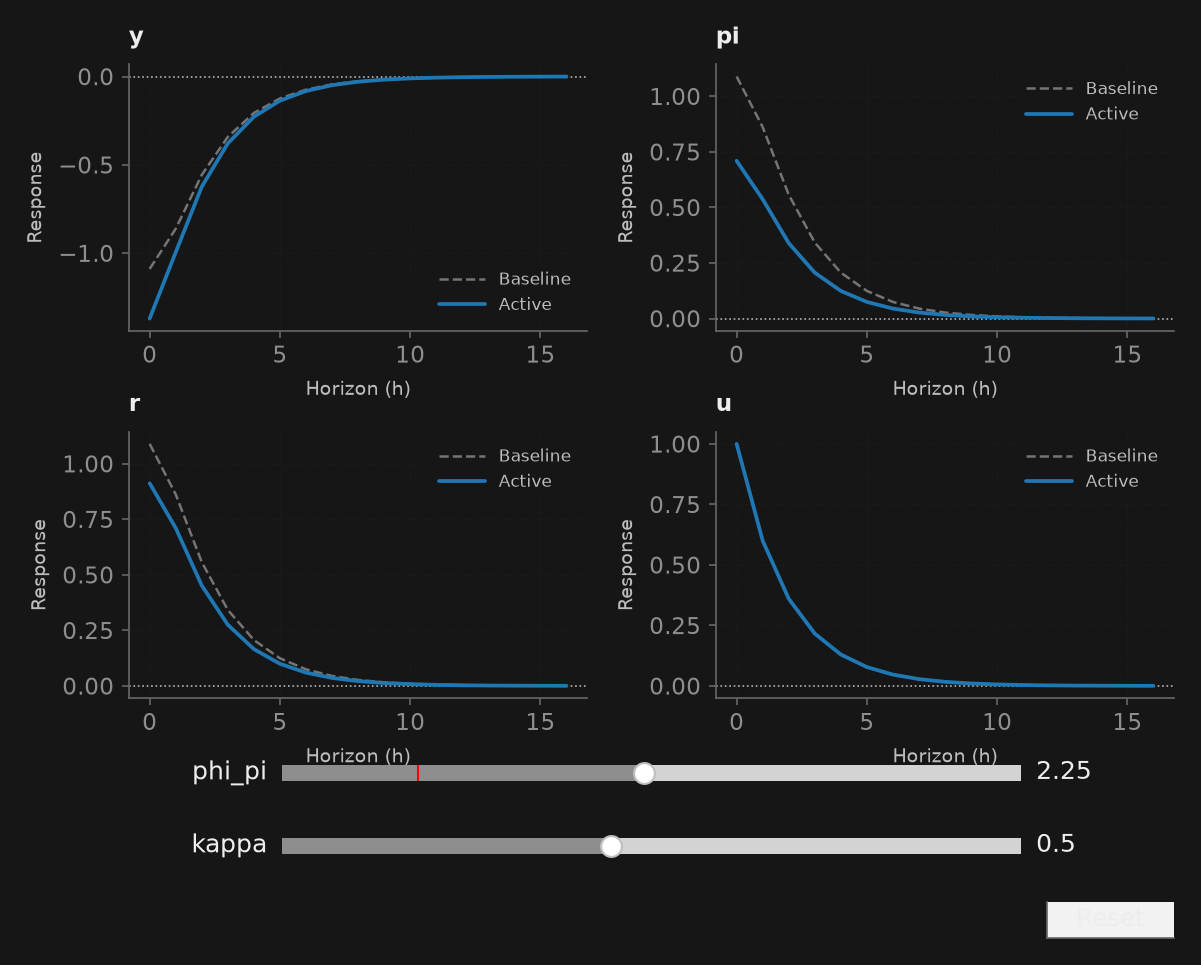

In [3]:
widget = interactive_irf(
    model_nk,
    parameters=["phi_pi", "kappa"],
    param_bounds={"phi_pi": (1.05, 3.5), "kappa": (0.1, 1.0)},
    horizon=16,
)

# Test instantaneous programmatic parameter update (mimicking slider drag)
widget.set_value("phi_pi", 2.25)

print("--- Interactive Slider Performance ---")
print(f"Active parameters : {list(widget.get_values().keys())}")
print(f"Live latency      : {widget.last_latency_ms:.0f} ms (machine-dependent)")
print(f"Updated phi_pi    : {widget.get_values()['phi_pi']:.2f}")

### Formal Parameter Rank Identification (Iskrev 2010; Komunjer & Ng 2011)

Before conducting policy optimization or Bayesian estimation, researchers must verify that structural parameters are locally identified. We evaluate both the Iskrev (2010) solution Jacobian $J_1$ and moment Jacobian $J_2$, alongside the Komunjer & Ng (2011) transfer function rank $J_H$ and spectral density rank $J_S$. All four observables ($y, \pi, r, u$) are treated as observed, and the Jacobians are evaluated at the calibration.

In [4]:
ident_res = identification(model_nk, lags=1)
print(ident_res.summary())

# Verify rank diagnostics
print(f"J1 Solution Rank : {ident_res.j1_rank} / {ident_res.n_params}")
print(f"J2 Moments Rank  : {ident_res.j2_rank} / {ident_res.n_params}")
print(f"JH Transfer Rank : {ident_res.jh_rank} / {ident_res.n_params}")

PARAMETER IDENTIFICATION ANALYSIS (Iskrev 2010 / Komunjer-Ng 2011)
Overall status         : UNIDENTIFIED (RANK DEFICIENT)
Parameters evaluated   : 7
Observables (varobs)   : y, pi, r, u
Autocovariance lags    : 1
Frequency grid points  : 16
J1 (Solution) rank     : 5 / 7 (DEFICIENT by 2)
J2 (Moments) rank      : 5 / 7 (DEFICIENT by 2)
JH (Transfer) rank     : 5 / 7 (DEFICIENT by 2)
JS (Spectrum) rank     : 5 / 7 (DEFICIENT by 2)

RANK CRITERIA SCORECARD
------------------------------------------------------------------------
                    criterion  rank  total  deficiency  condition_number          status
J1       J1 (Iskrev Solution)     5      7           2               inf  DEFICIENT by 2
J2   J2 (Iskrev Moments, p=1)     5      7           2               inf  DEFICIENT by 2
JH  JH (Komunjer-Ng Transfer)     5      7           2               inf  DEFICIENT by 2
JS  JS (Komunjer-Ng Spectrum)     5      7           2               inf  DEFICIENT by 2

J1 NULL SPACE PARAMETER

The model is **not** identified at this calibration: every criterion has rank 5 of 7. The first null direction moves $\phi_\pi$ and $\phi_y$ up together. The cell below shows why: with $\sigma = 1$ and $\phi_\pi - \phi_y = 1$, the path $y_t = -\pi_t$ satisfies the IS curve exactly, so the Taylor rule only ever sees $(\phi_\pi - \phi_y)\,\pi_t$. We check that $y_t + \pi_t$ is zero along the cost-push response, and re-run the analysis at $\phi_y = 0.25$, which breaks the knife edge.

In [5]:
irf_u = model_nk.irf("eps_u", horizon=12)
gap_y_pi = float(np.max(np.abs(irf_u["y"] + irf_u["pi"])))

model_nk_alt = build_dynare(preprocess_macro(NK_MACRO_SRC.replace("phi_y   = 0.50;", "phi_y   = 0.25;")))
ident_alt = identification(model_nk_alt, lags=1)

print(f"max |y_t + pi_t| along the cost-push IRF : {gap_y_pi:.1e}")
print(f"J2 rank at phi_y = 0.50                  : {ident_res.j2_rank} / {ident_res.n_params}")
print(f"J2 rank at phi_y = 0.25                  : {ident_alt.j2_rank} / {ident_alt.n_params}")
print(f"Remaining J2 null direction at 0.25      : {ident_alt.j2_null_combinations[0]}")

assert gap_y_pi < 1e-10, "y = -pi must hold exactly when sigma = 1 and phi_pi - phi_y = 1"
assert ident_res.j2_rank == ident_res.n_params - 2
assert ident_alt.j2_rank == ident_res.j2_rank + 1

max |y_t + pi_t| along the cost-push IRF : 2.2e-16
J2 rank at phi_y = 0.50                  : 5 / 7
J2 rank at phi_y = 0.25                  : 6 / 7
Remaining J2 null direction at 0.25      : 0.9560 * beta + 0.2293 * kappa + 0.1829 * gamma_p = 0


## 2. Optimal Monetary Policy: Discretion vs Commitment

We now contrast the time-consistent **Markov-perfect Discretionary Policy** (Dennis 2007) with the **commitment** benchmark: the Ramsey plan started from the steady state, whose law of motion is the timeless-perspective one.

The central bank minimizes the quadratic loss function:
$$ \mathcal{L}_t = \mathbb{E}_t \sum_{\tau=0}^\infty \beta^\tau \left[ \pi_{t+\tau}^2 + 0.25 (y_{t+\tau} - y^*)^2 \right] $$
where $y^* = 0.05$ is an output-gap target of 5% (for example, a response to monopolistic-competition distortions).

In [6]:
target_output = 0.05
loss_weights = {"pi": 1.0, "y": 0.25}

# Solve discretionary policy with automated commitment benchmark comparison
policy_res = optimal_policy(
    model_nk,
    loss=loss_weights,
    rule="discretion",
    instruments="r",
    y_star=target_output,
    compare_commitment=True,
    tol=1e-9,
    max_iter=2000,
)

print(policy_res.summary())

OPTIMAL POLICY REGIME: DISCRETION (DENNIS 2007)
Policymaker discount (beta): 0.9900
Expected unconditional loss : 1.547488e-04
Conditional loss (from s.s.): 1.536502e-04
Policy instruments          : r
Target variables            : pi (w=1.0), y (w=0.25)
Convergence status          : Converged in 14 iterations (diff=8.09e-10)
Inflation bias (E[pi^disc] - E[pi^comm]): 2.475248e-02
Stabilization bias (Loss^disc - Loss^comm, unconditional): 3.712375e-05
Riccati value matrix (norm) : 5.784186e-01

POLICY REACTION FUNCTIONS (Coefficients on States)
------------------------------------------------------------------------
     y        pi         u    r
r -0.0  0.269297  0.500897 -0.0


### Welfare Quantification: Inflation Bias & Stabilization Bias

1. **Inflation Bias**: Because $y^* > 0$, the discretionary policymaker is tempted to create surprise inflation to raise output. Price-setters anticipate this, so average inflation is higher without any systematic output gain ($E[\pi^{\text{disc}}] > 0$). Under commitment, average inflation is zero.
2. **Stabilization Bias**: After a cost-push shock, a committed central bank promises to keep output below potential even after the shock has faded. That promise lowers expected inflation and softens the trade-off today. Under discretion no such promise is credible. The losses below are unconditional expectations (`loss_criterion="unconditional"`); `stabilization_bias` is their difference, and it is NaN when no commitment solution was computed.

In [7]:
loss_gain_pct = 100.0 * policy_res.stabilization_bias / policy_res.loss

print("--- Welfare Bias Breakdown ---")
print(f"Output Gap Target (y*)                : {target_output:+.4f}")
print(f"Inflation Bias (E[pi] gap)            : {policy_res.inflation_bias:+.6f}")
print(f"Expected Loss under Discretion        : {policy_res.loss:.4e}")
print(f"Expected Loss under Commitment        : {policy_res.commitment_result.loss:.4e}")
print(f"Stabilization Bias (Excess Loss)      : {policy_res.stabilization_bias:.4e}")
print(f"Loss saved by commitment (% of disc.) : {loss_gain_pct:.1f}%")

# Analytical assertions
assert policy_res.converged, "Riccati policy iteration must converge"
assert policy_res.inflation_bias > 0.0, "Positive y* must generate positive inflation bias"
assert policy_res.stabilization_bias > 0.0, "At beta = 0.99 discretion also loses on average (unconditional loss)"

--- Welfare Bias Breakdown ---
Output Gap Target (y*)                : +0.0500
Inflation Bias (E[pi] gap)            : +0.024752
Expected Loss under Discretion        : 1.5475e-04
Expected Loss under Commitment        : 1.1763e-04
Stabilization Bias (Excess Loss)      : 3.7124e-05
Loss saved by commitment (% of disc.) : 24.0%


We plot the impulse responses to a one-standard-deviation cost-push shock ($\sigma_u = 1\%$) under discretion and under commitment, computed from the two solved closed-loop models.

Impact output gap (pp)  : discretion -1.495, commitment -1.188
Impact inflation (pp)   : discretion +0.542, commitment +0.441
Lowest inflation under commitment (pp): -0.100


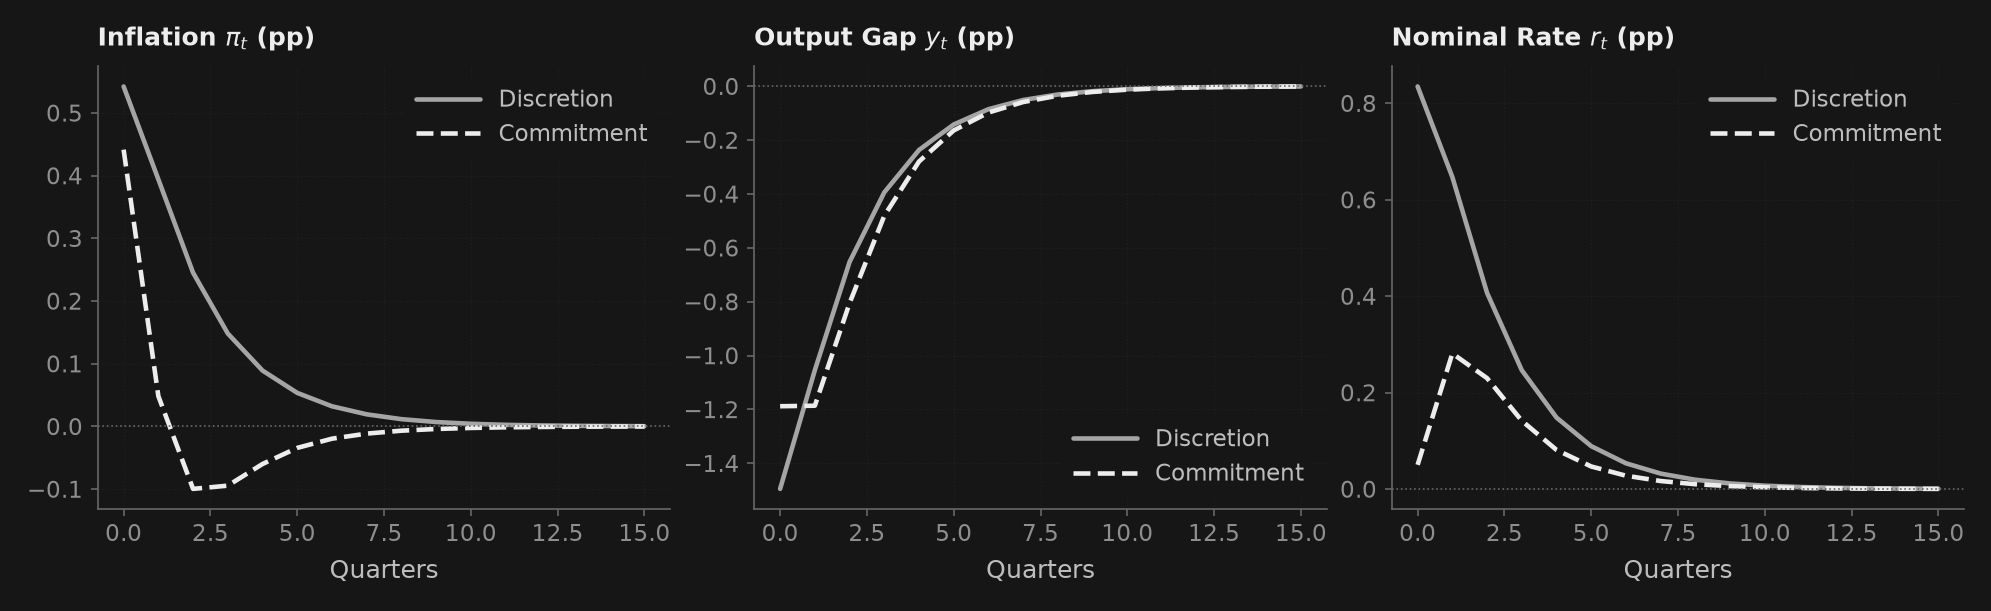

In [8]:
H = 16
sd_u = float(np.sqrt(model_nk._shock_cov[0, 0]))  # stderr of eps_u from the shocks block
irf_disc = policy_res.linear_model.irf("eps_u", horizon=H - 1) * sd_u * 100.0
irf_comm = policy_res.commitment_result.linear_model.irf("eps_u", horizon=H - 1) * sd_u * 100.0

y0_disc, y0_comm = float(irf_disc["y"].iloc[0]), float(irf_comm["y"].iloc[0])
pi0_disc, pi0_comm = float(irf_disc["pi"].iloc[0]), float(irf_comm["pi"].iloc[0])
pi_min_comm = float(irf_comm["pi"].min())
print(f"Impact output gap (pp)  : discretion {y0_disc:+.3f}, commitment {y0_comm:+.3f}")
print(f"Impact inflation (pp)   : discretion {pi0_disc:+.3f}, commitment {pi0_comm:+.3f}")
print(f"Lowest inflation under commitment (pp): {pi_min_comm:+.3f}")
assert y0_disc < y0_comm < 0.0, "commitment dampens the impact recession"
assert pi_min_comm < 0.0 < float(irf_disc["pi"].min()), "only commitment undershoots inflation"

fig, axes = _nbstyle.figura(1, 3, figsize=(13, 3.8))
for ax, var, title in zip(axes, ["pi", "y", "r"],
                          [r"Inflation $\pi_t$ (pp)", r"Output Gap $y_t$ (pp)", r"Nominal Rate $r_t$ (pp)"]):
    ax.plot(np.arange(H), irf_disc[var].to_numpy(), label="Discretion", color=_nbstyle.S2["color"], lw=2.2)
    ax.plot(np.arange(H), irf_comm[var].to_numpy(), label="Commitment", color=_nbstyle.S1["color"], lw=2.2, linestyle="--")
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, linestyle=":")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Quarters")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

## 3. DSGE-VAR Hybrid Modeling (Del Negro & Schorfheide 2004)

Next, we bridge the theoretical DSGE model with an unrestricted VAR(1) system for macroeconomic time series $Y_t = [y_t, \pi_t, r_t]'$.

First, we specify a 3-shock New Keynesian model with technology ($a_t$), cost-push ($u_t$), and monetary policy ($r_t$) innovations. We simulate $T=250$ quarters of synthetic data **from this same model** and evaluate the log marginal data density across the prior tightness grid $\lambda \in [0.25, 5.0]$:

In [9]:
NK_DSGE_VAR_MOD = """
var y pi r a u;
varexo eps_a eps_u eps_r;

parameters beta sigma kappa phi_pi phi_y rho_a rho_u;
beta   = 0.99;
sigma  = 1.00;
kappa  = 0.25;
phi_pi = 1.50;
phi_y  = 0.25;
rho_a  = 0.80;
rho_u  = 0.50;

model;
  y = y(+1) - (1/sigma)*(r - pi(+1)) + (a(+1) - a);
  pi = beta*pi(+1) + kappa*y + u;
  r = phi_pi*pi + phi_y*y + eps_r;
  a = rho_a*a(-1) + eps_a;
  u = rho_u*u(-1) + eps_u;
end;

shocks;
  var eps_a; stderr 0.010;
  var eps_u; stderr 0.008;
  var eps_r; stderr 0.004;
end;
"""

m_dsge_var = build_dynare(NK_DSGE_VAR_MOD)
sim_data = m_dsge_var.simulate(250, seed=123)[["y", "pi", "r"]]

print("--- Simulated Macroeconomic Data ---")
print(sim_data.describe().round(4))

--- Simulated Macroeconomic Data ---
              y        pi         r
count  250.0000  250.0000  250.0000
mean    -0.0011    0.0009    0.0013
std      0.0156    0.0113    0.0139
min     -0.0347   -0.0296   -0.0373
25%     -0.0128   -0.0070   -0.0077
50%     -0.0022    0.0024    0.0021
75%      0.0097    0.0089    0.0116
max      0.0391    0.0262    0.0339


We estimate the DSGE-VAR(1) model across candidate values of the prior weight $\lambda$. When $\lambda \to \lambda_{\min}$, the estimator approaches the unconstrained OLS VAR; when $\lambda \to \infty$, it strictly imposes the theoretical DSGE restrictions:

In [10]:
lambda_grid = [0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00, 5.00]

res_dvar = estimate_dsge_var(
    model=m_dsge_var,
    data=sim_data,
    p=1,
    lamb="optimal",
    lambda_grid=lambda_grid,
)

print(res_dvar.summary())

DSGE-VAR Estimation (Del Negro & Schorfheide 2004)
Sample size (T):           249 (Effective after 1 lags)
Observables (n):           3 (y, pi, r)
Structural shocks:         3 (eps_a, eps_u, eps_r)
VAR lag order (p):         1
Identification:            dsge
------------------------------------------------------------------------------
Prior weight (lambda):     5.0000
Admissibility bound (min): 0.0281 = (k + n) / T
Optimal lambda (hat):      5.0000
Log Marginal Data Density: 2829.4901
Estimated VAR Coefficients (tilde{Phi}):
            y      pi       r
const -0.0001  0.0001  0.0001
L1.y   0.5105  0.0846  0.2531
L1.pi -0.4424  0.3791  0.4707
L1.r   0.3935  0.1984  0.3866
------------------------------------------------------------------------------
Posterior Innovation Covariance (tilde{Sigma}):
           y        pi         r
y   0.000173 -0.000118 -0.000144
pi -0.000118  0.000095  0.000111
r  -0.000144  0.000111  0.000141
-----------------------------------------------------------

### Marginal Data Density Optimization Profile

We plot the log marginal data density $\ln p(Y \mid \lambda, \theta)$ as a function of the prior weight $\lambda$. An interior peak would say that some but not all of the DSGE restrictions help; a peak at the largest $\lambda$ says the data want as much of the model as the grid allows.

 lambda  log_mdd
   0.25  2820.55
   0.50  2824.40
   0.75  2826.07
   1.00  2827.00
   1.50  2828.01
   2.00  2828.53
   3.00  2829.07
   4.00  2829.33
   5.00  2829.49
Optimal prior weight hat(lambda) : 5.0000 (largest grid value: 5.00)
Log MDD at optimum               : 2829.49
Log MDD rises at every grid step : True


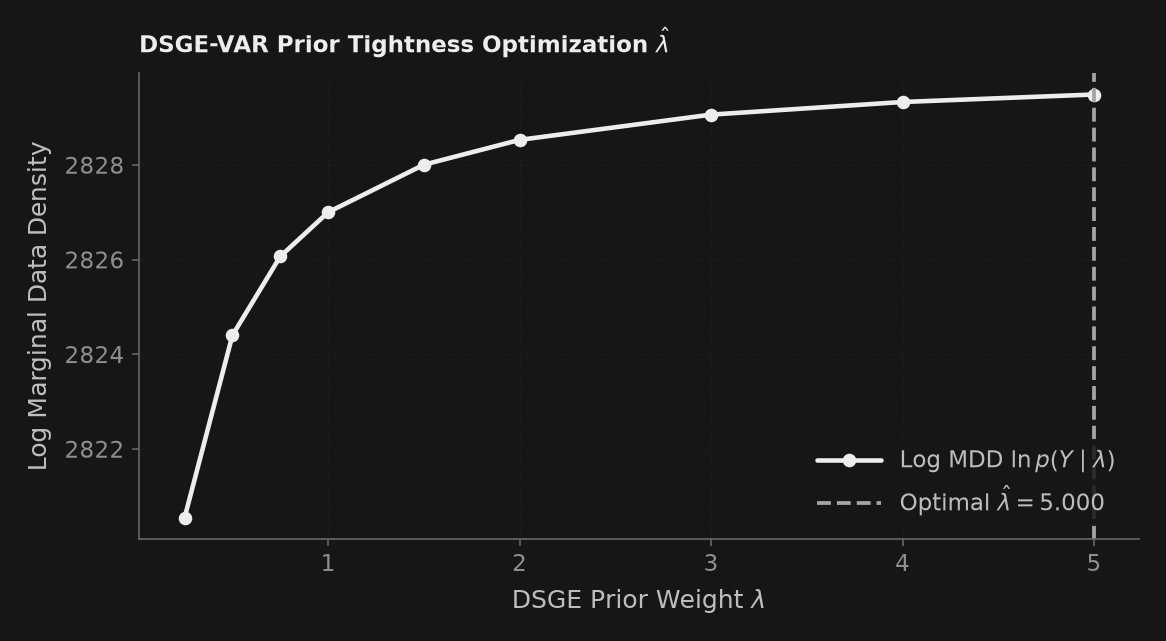

In [11]:
grid_df = res_dvar.log_mdd_grid
mdd_steps = np.diff(grid_df["log_mdd"].to_numpy())

fig, ax = _nbstyle.figura(1, 1, figsize=(7.5, 4.0))
ax.plot(grid_df["lambda"], grid_df["log_mdd"], marker="o", color=_nbstyle.S1["color"], lw=2.2, label=r"Log MDD $\ln p(Y \mid \lambda)$")
ax.axvline(res_dvar.hat_lambda, color=_nbstyle.S2["color"], linestyle="--", lw=1.8, label=rf"Optimal $\hat{{\lambda}} = {res_dvar.hat_lambda:.3f}$")
ax.set_title(r"DSGE-VAR Prior Tightness Optimization $\hat{\lambda}$", fontsize=11, fontweight="bold")
ax.set_xlabel(r"DSGE Prior Weight $\lambda$")
ax.set_ylabel("Log Marginal Data Density")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right")

print(grid_df.round(2).to_string(index=False))
print(f"Optimal prior weight hat(lambda) : {res_dvar.hat_lambda:.4f} (largest grid value: {max(lambda_grid):.2f})")
print(f"Log MDD at optimum               : {res_dvar.log_mdd:.2f}")
print(f"Log MDD rises at every grid step : {bool(np.all(mdd_steps > 0))}")

## 4. Anticipated & News Shocks Engine (Beaudry & Portier 2006)

How do economies react to credible announcements of future innovations?

We examine an anticipated technology news shock announced at $t=0$ with a lead of $k=4$ quarters: news arrives today that the technology process $a_t$ will receive a unit innovation at $t=4$.

The construction guarantees three properties that we check numerically:
1. **Zero State Revision**: The exogenous technology state cannot move ahead of time ($a_t = 0$ for $t < 4$).
2. **Forward-Looking Control Jump**: Because households and firms form rational expectations, output, inflation and the policy rate move at $t=0$ upon hearing the announcement.
3. **Exact Shock Materialization**: At date $t=4$, the shock innovation realizes exactly ($a_4 = 1.0$).

In [12]:
# Solve News IRF for technology shock with 4-quarter anticipation lead
news_res = news_irf(m_dsge_var, shock="eps_a", lead=4, horizon=16)

print(news_res.summary())

# Extract impulse responses
irf_df = news_res.irf
a_path = irf_df["a"].to_numpy()
y_path = irf_df["y"].to_numpy()
pi_path = irf_df["pi"].to_numpy()
r_path = irf_df["r"].to_numpy()

# Mathematical property checks
max_pre_realiz_a = np.max(np.abs(a_path[:4]))
impact_y = y_path[0]
impact_pi = pi_path[0]
realiz_a = a_path[4]

print("\n--- Empirical Verification of News Properties ---")
print(f"1. Max physical state revision for t < 4 : {max_pre_realiz_a:.1e} (0 up to rounding)")
print(f"2. Output gap jump at announcement (t=0) : {impact_y:+.4f}")
print(f"3. Inflation jump at announcement (t=0)  : {impact_pi:+.4f}")
print(f"4. Exact realization at date t=4        : {realiz_a:+.4f} (unit innovation)")

assert np.isclose(max_pre_realiz_a, 0.0, atol=1e-12), "Predetermined state cannot change before realization"
assert not np.isclose(impact_pi, 0.0, atol=1e-4), "Forward-looking controls must jump at announcement"
assert np.isclose(realiz_a, 1.0, atol=1e-6), "Shock must materialize at scheduled horizon"

News Shock IRF Summary: shock='eps_a', lead=4, horizon=16, size=1.0
------------------------------------------------------------------------------
Variable     Impact (t=0)   Pre-realiz     Realiz (t=k)   Peak Dev       Peak t  
------------------------------------------------------------------------------
y                  0.0983        0.5756       -0.1549        0.5756  3       
pi                 0.1271       -0.0404       -0.1862       -0.1862  4       
r                  0.2153        0.0833       -0.3179       -0.3179  4       
a                  0.0000        0.0000        1.0000        1.0000  4       
u                  0.0000        0.0000        0.0000       -0.0000  1       

--- Empirical Verification of News Properties ---
1. Max physical state revision for t < 4 : 2.3e-16 (0 up to rounding)
2. Output gap jump at announcement (t=0) : +0.0983
3. Inflation jump at announcement (t=0)  : +0.1271
4. Exact realization at date t=4        : +1.0000 (unit innovation)


We plot the trajectory of the anticipated shock from announcement through realization:

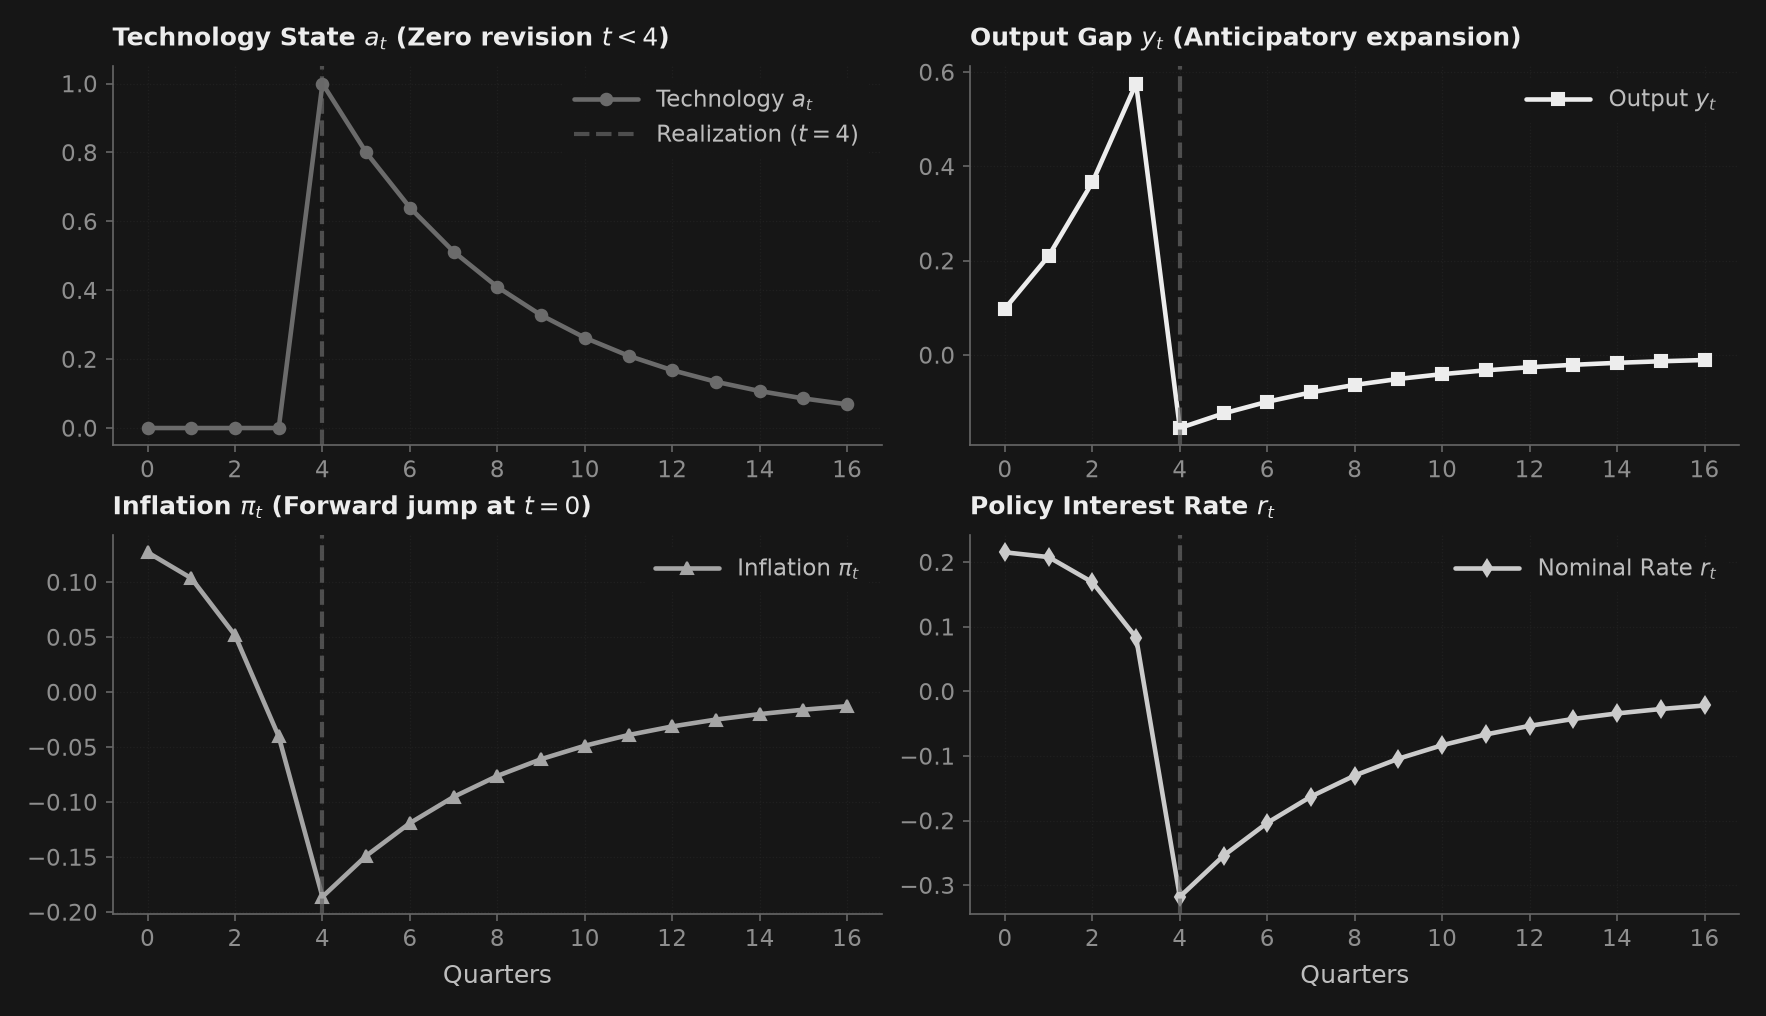

In [13]:
fig, axes = _nbstyle.figura(2, 2, figsize=(11.5, 6.5))

time_axis = np.arange(len(a_path))

# Panel 1: Exogenous technology state
axes[0, 0].plot(time_axis, a_path, color=_nbstyle.S3["color"], lw=2.2, marker="o", label="Technology $a_t$")
axes[0, 0].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7, label="Realization ($t=4$)")
axes[0, 0].set_title(r"Technology State $a_t$ (Zero revision $t < 4$)", fontweight="bold")
axes[0, 0].grid(True, linestyle=":", alpha=0.6)
axes[0, 0].legend()

# Panel 2: Output gap
axes[0, 1].plot(time_axis, y_path, color=_nbstyle.S1["color"], lw=2.2, marker="s", label="Output $y_t$")
axes[0, 1].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[0, 1].set_title(r"Output Gap $y_t$ (Anticipatory expansion)", fontweight="bold")
axes[0, 1].grid(True, linestyle=":", alpha=0.6)
axes[0, 1].legend()

# Panel 3: Inflation
axes[1, 0].plot(time_axis, pi_path, color=_nbstyle.S2["color"], lw=2.2, marker="^", label=r"Inflation $\pi_t$")
axes[1, 0].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[1, 0].set_title(r"Inflation $\pi_t$ (Forward jump at $t=0$)", fontweight="bold")
axes[1, 0].set_xlabel("Quarters")
axes[1, 0].grid(True, linestyle=":", alpha=0.6)
axes[1, 0].legend()

# Panel 4: Policy rate
axes[1, 1].plot(time_axis, r_path, color=_nbstyle.S4["color"], lw=2.2, marker="d", label="Nominal Rate $r_t$")
axes[1, 1].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[1, 1].set_title(r"Policy Interest Rate $r_t$", fontweight="bold")
axes[1, 1].set_xlabel("Quarters")
axes[1, 1].grid(True, linestyle=":", alpha=0.6)
axes[1, 1].legend()

### Forecast Error Variance Decomposition: Surprise vs. News Leads

What fraction of the forecast-error variance of each variable comes from the surprise component and from each news lead $k \in \{1, 2, 3, 4\}$? `decompose_news` gives the surprise and every lead a **unit innovation variance**, so these shares describe the propagation of equally sized innovations, not an estimate of how important news is in the data.

In [14]:
decomp = decompose_news(m_dsge_var, shock="eps_a", max_lead=4, horizon=16)

print(decomp.summary())

# Verify row stochasticity: shares must sum to 1.0
fevd_shares = decomp.variance_shares
print("\nVariance Shares at Horizon H=16:")
print(fevd_shares.round(4))

News Shock Variance Decomposition: shock='eps_a', horizon=16, max_lead=4
------------------------------------------------------------------------------
    surprise  news_1  news_2  news_3  news_4  total_news
y     0.0309  0.1844  0.2465  0.2669  0.2714      0.9691
pi    0.1806  0.1836  0.1885  0.2085  0.2387      0.8194
r     0.1703  0.1745  0.1917  0.2178  0.2457      0.8297
a     0.2002  0.2001  0.2001  0.1999  0.1997      0.7998
u     1.0000  0.0000  0.0000  0.0000  0.0000      0.0000

Variance Shares at Horizon H=16:
    surprise  news_1  news_2  news_3  news_4
y     0.0309  0.1844  0.2465  0.2669  0.2714
pi    0.1806  0.1836  0.1885  0.2085  0.2387
r     0.1703  0.1745  0.1917  0.2178  0.2457
a     0.2002  0.2001  0.2001  0.1999  0.1997
u     1.0000  0.0000  0.0000  0.0000  0.0000


## 5. Publication-Ready Scientific Reporting

Finally, we export our optimal policy comparison, DSGE-VAR estimates, and news decomposition tables to LaTeX, Typst, and Markdown for academic papers and policy briefings:

In [15]:
print("--- LaTeX Table Export: Optimal Policy Comparison ---")
print(policy_res.to_latex())

print("--- Markdown Table Export: News Variance Decomposition ---")
print(decomp.to_markdown())

--- LaTeX Table Export: Optimal Policy Comparison ---
\begin{tabular}{lrrrr}
index & y & pi & u & r \\
\hline
r & 0 & 0.269297 & 0.500897 & 0 \\
\end{tabular}
--- Markdown Table Export: News Variance Decomposition ---
| index | surprise |   news_1 |   news_2 |   news_3 |   news_4 |
|-------|----------|----------|----------|----------|----------|
|     y | 0.030854 |  0.18436 | 0.246506 | 0.266917 | 0.271362 |
|    pi | 0.180607 | 0.183617 | 0.188534 |  0.20855 | 0.238692 |
|     r | 0.170293 | 0.174458 | 0.191705 | 0.217806 | 0.245738 |
|     a | 0.200199 | 0.200142 | 0.200052 | 0.199913 | 0.199695 |
|     u |        1 |        0 |        0 |        0 |        0 |


## Read the output

**Read the output.**
1. **Macro processing and identification.** The preprocessor keeps the indexation branch, so `pi` becomes a predetermined state; the model has 2 stable roots for its 2 states and is determinate. It is **not** identified at this calibration: $J_1$, $J_2$, $J_H$ and $J_S$ all have rank 5 of 7. One null direction raises $\phi_\pi$ and $\phi_y$ together; it exists because $\sigma = 1$ and $\phi_\pi - \phi_y = 1$ make $y_t = -\pi_t$ an exact equilibrium relation (max $|y_t + \pi_t|$ is below 1e-12 along the cost-push response), so the rule only reveals $\phi_\pi - \phi_y$. At $\phi_y = 0.25$ the $J_2$ rank rises to 6 of 7; the remaining null direction is a combination of $\beta$, $\kappa$ and $\gamma_p$, the Phillips-curve parameters that a single shock cannot separate. Passing this check is necessary before estimation; failing it, as here, means the likelihood is flat along those directions.
2. **Discretion versus commitment.** With $y^* = 0.05$, discretion produces an inflation bias of +0.024752, while commitment keeps average inflation at zero. The unconditional loss is 1.5475e-04 under discretion and 1.1763e-04 under commitment, so commitment saves 24.0% of the discretionary loss (stabilization bias 3.7124e-05). The impulse responses show how: after a one-s.d. cost-push shock, output falls by 1.495 pp on impact under discretion but by 1.188 pp under commitment, and commitment keeps output below potential for longer and lets inflation undershoot (its lowest value is -0.100 pp) instead of letting it decay from above.
3. **DSGE-VAR.** The log marginal data density rises at every step of the grid, from 2820.55 at $\lambda = 0.25$ to 2829.49 at $\lambda = 5$, so $\hat{\lambda} = 5.0$ sits at the upper edge of the grid. This is a corner, not an interior optimum: the data were simulated from the very model that centres the prior, so the more weight the prior gets, the better. With real data or a misspecified prior model (see the intermediate exercise below) the profile can peak at small $\lambda$.
4. **News shocks.** For technology news four quarters ahead, the exogenous state stays at zero before $t = 4$ (largest deviation below 1e-12) and then realizes exactly ($a_4 = 1.0000$). Output (+0.0983), inflation (+0.1271) and the policy rate (+0.2153) all move at the announcement, and output keeps rising until it peaks at +0.5756 in quarter 3, just before the innovation lands. With equal innovation variances, news accounts for 96.9% of the 16-quarter forecast-error variance of output and 81.9% of inflation; these shares reflect the unit-variance assumption, not data.

## Your turn

The cell below re-solves discretion for another output target and news shocks for another lead. It checks two things that must hold for any admissible choice: the inflation bias is linear in $y^*$ (it is a linear-quadratic problem), and the output response at the announcement obeys the IS curve iterated forward, $y_0 = -\sum_{t\ge 0}(r_t - \pi_{t+1}) - a_0$, with the Taylor rule splitting the cumulative real rate into $(\phi_\pi - 1)\sum_t \pi_t + \phi_y \sum_t y_t + \pi_0$.

**Prompts.**
1. *Basic — where the inflation bias comes from.* Rebuild the Section 1 model without indexation (replace `@#define USE_INDEXATION = 1` by `= 0`). From the discretionary first-order condition $\kappa \pi + \lambda_y (y - y^*) = 0$ and the steady-state Phillips curve $(1 - \beta)\pi = \kappa y$, derive average inflation $\bar{\pi}(\kappa)$ in closed form and compare it with `optimal_policy(..., rule="discretion", y_star=target_output).inflation_bias` (they should agree to 1e-9). Then find analytically the $\kappa^*$ that maximises $\bar{\pi}$, and confirm it: rebuild the model for $\kappa = 0.01, 0.015, \dots, 0.20$ and check that the library's argmax is within one grid step of your $\kappa^*$. Why does the bias vanish as $\kappa \to 0$ when $\beta < 1$, why does it fall for large $\kappa$, and what would happen with $\beta = 1$?
2. *Intermediate — is $\hat{\lambda}$ a misspecification detector?* Simulate $T = 250$ quarters (seed 123) from a copy of `NK_DSGE_VAR_MOD` with interest-rate smoothing, `r = 0.8*r(-1) + 0.2*(phi_pi*pi + phi_y*y) + eps_r;`, and re-estimate the DSGE-VAR with the prior still centred on the static-rule model. Check that $\hat{\lambda}$ falls to the lower corner of its search range while the correctly specified run above stays at the upper corner, and that the misspecified log-MDD profile decreases at every step. Why can the two profiles' shapes be compared but not their levels? Repeat with seeds 1 and 2.
3. *Stretch — why the announcement effect changes sign.* Run `lead_yt = 2, 4, 8` in the cell below and record $y_0$. Use the printed split of the cumulative real rate to explain why output rises at the announcement for short leads but falls at $L = 8$. Which parts of the rate path are promised easing, and which are anticipatory tightening? Between which two leads does the sign flip?

In [16]:
# ← change this: output target y*, any value in [0.01, 0.10]
target_output_yt = 0.08
# ← change this: news lead in quarters, any integer in [1, 12]
lead_yt = 2
assert 0.01 <= target_output_yt <= 0.10 and lead_yt in range(1, 13)

# 1. Re-solve optimal policy under custom output gap target
policy_yt = optimal_policy(
    model_nk,
    loss=loss_weights,
    rule="discretion",
    instruments="r",
    y_star=target_output_yt,
    compare_commitment=True,
    tol=1e-9,
)

# 2. Re-solve news IRF under custom anticipation horizon (long horizon so the sums converge)
irf_yt = news_irf(m_dsge_var, shock="eps_a", lead=lead_yt, horizon=200).irf
y_n, pi_n, r_n, a_n = (irf_yt[k].to_numpy() for k in ("y", "pi", "r", "a"))
cum_rr = float(np.sum(r_n[:-1] - pi_n[1:]))
split = ((1.5 - 1.0) * pi_n.sum(), 0.25 * y_n.sum(), pi_n[0])  # phi_pi = 1.5, phi_y = 0.25 in NK_DSGE_VAR_MOD

print(f"Optimal Policy (y* = {target_output_yt:+.2f}):")
print(f"  Inflation bias : {policy_yt.inflation_bias:+.6f} (Baseline y*=0.05: {policy_res.inflation_bias:+.6f})")
print(f"  Bias per unit of y*: {policy_yt.inflation_bias / target_output_yt:.6f} (baseline {policy_res.inflation_bias / target_output:.6f})")
print(f"News Shock (Lead = {lead_yt} quarters):")
print(f"  Output at announcement y0      : {y_n[0]:+.4f}")
print(f"  Minus cumulative real rate     : {-cum_rr:+.4f}")
print(f"  Split (phi_pi-1)*sum(pi), phi_y*sum(y), pi0 : {split[0]:+.4f}, {split[1]:+.4f}, {split[2]:+.4f}")
print(f"  State at realization (t={lead_yt})  : {a_n[lead_yt]:+.4f}")

# Downstream automated assertions
assert policy_yt.converged
assert abs(policy_yt.inflation_bias / target_output_yt - policy_res.inflation_bias / target_output) < 1e-9, "bias must be linear in y*"
assert abs(y_n[0] + cum_rr + a_n[0]) < 1e-8, "IS curve iterated forward"
assert abs(cum_rr - sum(split)) < 1e-8, "Taylor-rule split of the cumulative real rate"
assert np.isclose(a_n[lead_yt], 1.0, atol=1e-6) and np.max(np.abs(a_n[:lead_yt])) < 1e-12

Optimal Policy (y* = +0.08):
  Inflation bias : +0.039604 (Baseline y*=0.05: +0.024752)
  Bias per unit of y*: 0.495050 (baseline 0.495050)
News Shock (Lead = 2 quarters):
  Output at announcement y0      : +0.3663
  Minus cumulative real rate     : +0.3663
  Split (phi_pi-1)*sum(pi), phi_y*sum(y), pi0 : -0.4598, +0.0419, +0.0516
  State at realization (t=2)  : +1.0000


## How comprehensive is this?

`puremacro.dsge` unifies the advanced frontier of structural rational expectations modeling in 100% pure Python:
- `optimal_policy`: Solves Markov-perfect discretionary policy (Dennis 2007; Oudiz & Sachs 1985) via matrix Riccati policy iteration and compares it with commitment from the steady state (Clarida, Galí & Gertler 1999), quantifying inflation and stabilization bias. Notebook 66 checks these solvers against the closed forms of Clarida, Galí & Gertler (1999).
- `estimate_dsge_var`: Implements Del Negro & Schorfheide (2004) DSGE-VAR($\lambda$) modeling, linking analytical cross-equation moments to inverted Wishart priors for formal model misspecification testing.
- `news_irf` and `decompose_news`: Provides state-space nilpotent companion augmentation for anticipated news shocks (Beaudry & Portier 2006; Schmitt-Grohé & Uribe 2012) and news-versus-surprise variance decompositions under equal innovation variances.
- `preprocess_macro`: Pure-Python Dynare macro preprocessor resolving `@#define`, `@#for`, `@#if`, and variable interpolation before AST compilation.
- `identification`: Computes Iskrev (2010) and Komunjer & Ng (2011) rank identification criteria across dynamic Jacobians, autocovariance moments, and spectral transfer functions.